In [1]:
%run Librerias.ipynb

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
epochs=10

# 1) PRIMER MODELO: 3% DE LAS IMÁGENES

In [3]:
train_dir_3 = r"C:\Datasets\imagenes_como_vienen\3%\dataset_train_jpg"
test_dir_3  = r"C:\Datasets\imagenes_como_vienen\3%\dataset_test_jpg"

In [4]:
train_ds_m1 = tf.keras.utils.image_dataset_from_directory(
    train_dir_3,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds_m1 = tf.keras.utils.image_dataset_from_directory(
    test_dir_3,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 10545 files belonging to 3 classes.
Found 2676 files belonging to 3 classes.


In [5]:
class_names = train_ds_m1.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds_m1 = train_ds_m1.prefetch(AUTOTUNE)
test_ds_m1 = test_ds_m1.prefetch(AUTOTUNE)

In [6]:
print(class_names)

['Comestible', 'No comestible', 'Venenoso']


**CHEQUEO DE CLASES**

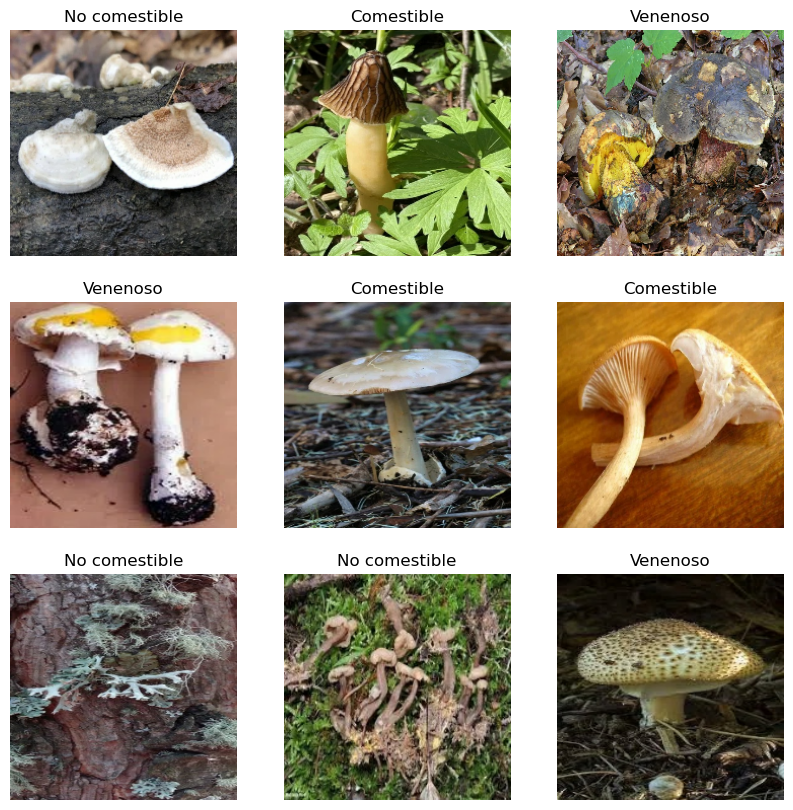

In [7]:
plt.figure(figsize=(10,10))

for images, labels in train_ds_m1.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [9]:
base_model.trainable = False

In [10]:
inputs = tf.keras.Input(shape=(224,224,3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    3,
    activation="softmax"
)(x)

model_m1 = tf.keras.Model(inputs, outputs)

In [11]:
model_m1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
model_m1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │           3,843 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
%%time
history_m1 = model_m1.fit(
    train_ds_m1,
    validation_data=test_ds_m1,
    epochs=epochs
)

Epoch 1/10
330/330 ━━━━━━━━━━━━━━━━━━━━ 196s 561ms/step - accuracy: 0.5345 - loss: 0.9844 - val_accuracy: 0.5336 - val_loss: 0.9536
Epoch 2/10
330/330 ━━━━━━━━━━━━━━━━━━━━ 168s 509ms/step - accuracy: 0.5881 - loss: 0.8927 - val_accuracy: 0.5602 - val_loss: 0.8995
Epoch 3/10
330/330 ━━━━━━━━━━━━━━━━━━━━ 170s 515ms/step - accuracy: 0.6071 - loss: 0.8552 - val_accuracy: 0.5602 - val_loss: 0.9033
Epoch 4/10
330/330 ━━━━━━━━━━━━━━━━━━━━ 166s 505ms/step - accuracy: 0.6207 - loss: 0.8295 - val_accuracy: 0.5340 - val_loss: 0.9451
Epoch 5/10
330/330 ━━━━━━━━━━━━━━━━━━━━ 171s 519ms/step - accuracy: 0.6206 - loss: 0.8302 - val_accuracy: 0.5501 - val_loss: 0.9527
Epoch 6/10
330/330 ━━━━━━━━━━━━━━━━━━━━ 167s 505ms/step - accuracy: 0.6229 - loss: 0.8218 - val_accuracy: 0.5646 - val_loss: 0.8985
Epoch 7/10
330/330 ━━━━━━━━━━━━━━━━━━━━ 168s 508ms/step - accuracy: 0.6271 - loss: 0.8137 - val_accuracy: 0.5456 - val_loss: 0.9364
Epoch 8/10
330/330 ━━━━━━━━━━━━━━━━━━━━ 172s 520ms/step - accuracy: 0.6288 -

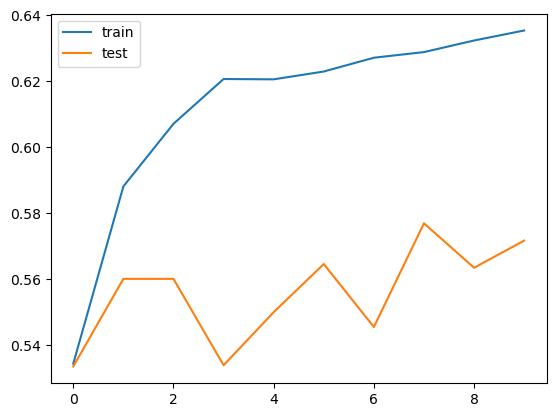

In [14]:
plt.plot(history_m1.history["accuracy"], label="train")
plt.plot(history_m1.history["val_accuracy"], label="test")

plt.legend()
plt.show()

In [15]:
%%time

y_true_m1 = []
y_pred_m1 = []

for x, y in test_ds_m1:
    pred = model_m1.predict(x, verbose=0)

    y_true_m1.extend(y.numpy())
    y_pred_m1.extend(np.argmax(pred, axis=1))

print(classification_report(y_true_m1, y_pred_m1))

              precision    recall  f1-score   support

           0       0.58      0.44      0.50       971
           1       0.55      0.73      0.62      1043
           2       0.63      0.52      0.57       662

    accuracy                           0.57      2676
   macro avg       0.58      0.56      0.56      2676
weighted avg       0.58      0.57      0.56      2676

CPU times: total: 5min 29s
Wall time: 57.2 s


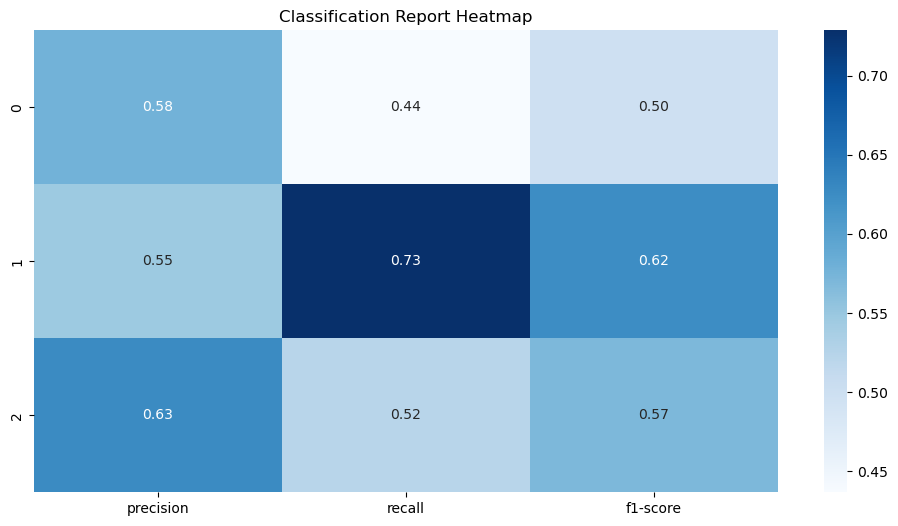

In [16]:
report_m1 = classification_report(y_true_m1, y_pred_m1, output_dict=True)
df_m1 = pd.DataFrame(report_m1).transpose()

plt.figure(figsize=(12,6))
sns.heatmap(df_m1[['precision', 'recall', 'f1-score']].head(3), annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.show()

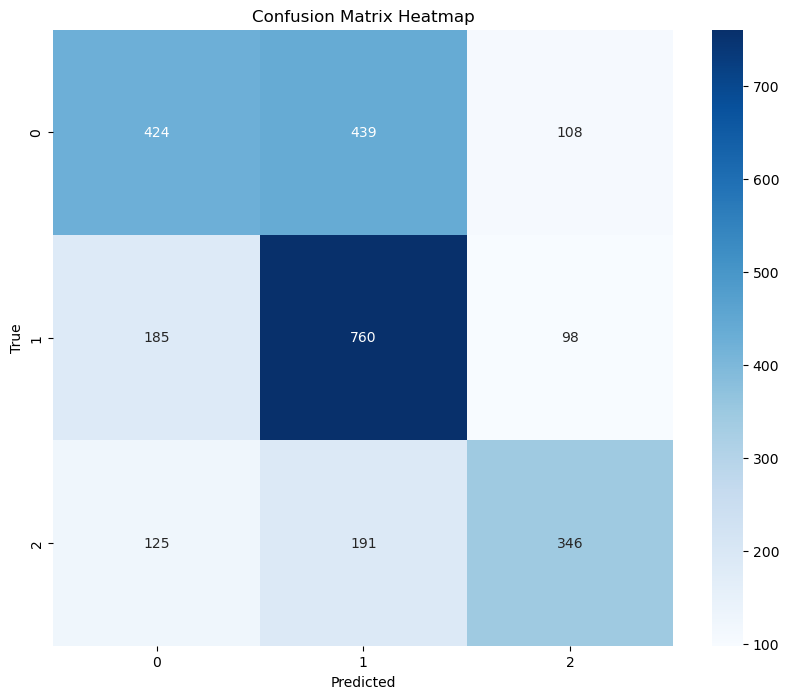

In [17]:
# Calcular matriz de confusión
cm_m1 = confusion_matrix(y_true_m1, y_pred_m1)

# Graficar heatmap con enteros
plt.figure(figsize=(10,8))
sns.heatmap(cm_m1, annot=True, cmap="Blues", cbar=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [18]:
model_m1.save("hongos_m1.keras")

In [19]:
%%time
loss, accuracy = model_m1.evaluate(test_ds_m1)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 417ms/step - accuracy: 0.5717 - loss: 0.9009
Loss: 0.9009
Accuracy: 0.5717
CPU times: total: 4min 58s
Wall time: 35.2 s


# 2) SEGUNDO MODELO: 15% DE LAS IMÁGENES

In [20]:
train_dir_15 = r"C:\Datasets\imagenes_como_vienen\15%\dataset_train_jpg"
test_dir_15  = r"C:\Datasets\imagenes_como_vienen\15%\dataset_test_jpg"

In [21]:
train_ds_m2 = tf.keras.utils.image_dataset_from_directory(
    train_dir_15,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds_m2 = tf.keras.utils.image_dataset_from_directory(
    test_dir_15,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 34561 files belonging to 3 classes.
Found 9574 files belonging to 3 classes.


In [22]:
class_names = train_ds_m2.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds_m2 = train_ds_m2.prefetch(AUTOTUNE)
test_ds_m2 = test_ds_m2.prefetch(AUTOTUNE)

In [23]:
print(class_names)

['Comestible', 'No comestible', 'Venenoso']


**CHEQUEO DE CLASES**

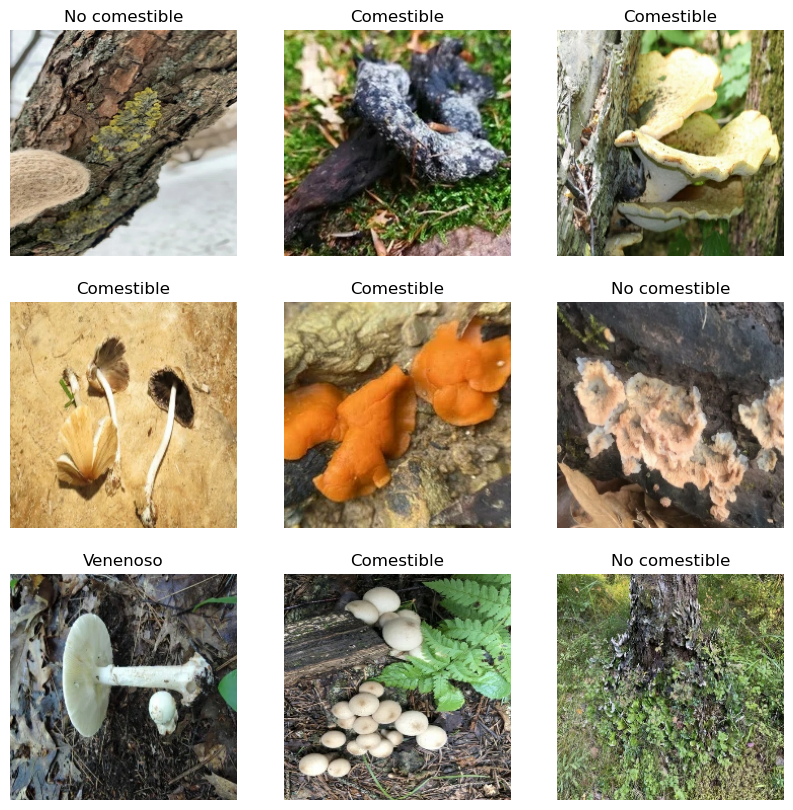

In [24]:
plt.figure(figsize=(10,10))

for images, labels in train_ds_m2.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [25]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [26]:
base_model.trainable = False

In [27]:
inputs = tf.keras.Input(shape=(224,224,3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    3,
    activation="softmax"
)(x)

model_m2 = tf.keras.Model(inputs, outputs)

In [28]:
model_m2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
model_m2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_1 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_1 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │           3,843 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
%%time
history_m2 = model_m2.fit(
    train_ds_m2,
    validation_data=test_ds_m2,
    epochs=epochs
)

Epoch 1/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 605s 550ms/step - accuracy: 0.5905 - loss: 0.8664 - val_accuracy: 0.5846 - val_loss: 0.8787
Epoch 2/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 572s 529ms/step - accuracy: 0.6282 - loss: 0.7984 - val_accuracy: 0.6044 - val_loss: 0.8650
Epoch 3/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 590s 546ms/step - accuracy: 0.6283 - loss: 0.7968 - val_accuracy: 0.6024 - val_loss: 0.8697
Epoch 4/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 599s 554ms/step - accuracy: 0.6331 - loss: 0.7937 - val_accuracy: 0.5882 - val_loss: 0.8904
Epoch 5/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 591s 547ms/step - accuracy: 0.6375 - loss: 0.7878 - val_accuracy: 0.5885 - val_loss: 0.8797
Epoch 6/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 602s 557ms/step - accuracy: 0.6360 - loss: 0.7897 - val_accuracy: 0.6146 - val_loss: 0.8786
Epoch 7/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 611s 565ms/step - accuracy: 0.6335 - loss: 0.7907 - val_accuracy: 0.5841 - val_loss: 0.8942
Epoch 8/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 591s 547ms/step - ac

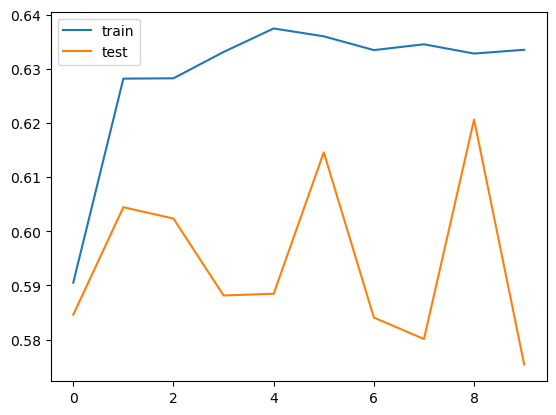

In [31]:
plt.plot(history_m2.history["accuracy"], label="train")
plt.plot(history_m2.history["val_accuracy"], label="test")

plt.legend()
plt.show()

In [32]:
%%time

y_true_m2 = []
y_pred_m2 = []

for x, y in test_ds_m2:
    pred = model_m2.predict(x, verbose=0)

    y_true_m2.extend(y.numpy())
    y_pred_m2.extend(np.argmax(pred, axis=1))

print(classification_report(y_true_m2, y_pred_m2))

              precision    recall  f1-score   support

           0       0.66      0.33      0.44      3792
           1       0.58      0.86      0.69      4248
           2       0.44      0.39      0.42      1534

    accuracy                           0.58      9574
   macro avg       0.56      0.53      0.52      9574
weighted avg       0.59      0.58      0.55      9574

CPU times: total: 19min 24s
Wall time: 3min 4s


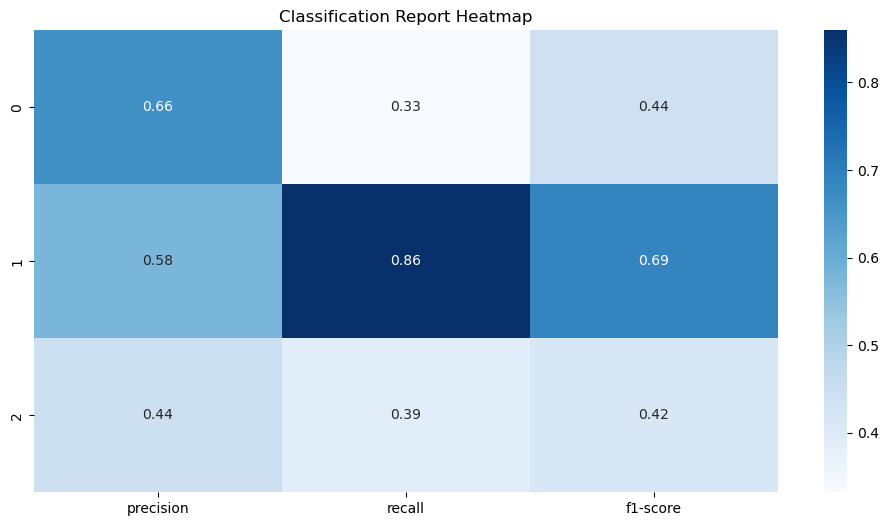

In [33]:
report_m2 = classification_report(y_true_m2, y_pred_m2, output_dict=True)
df_m2 = pd.DataFrame(report_m2).transpose()

plt.figure(figsize=(12,6))
sns.heatmap(df_m2[['precision', 'recall', 'f1-score']].head(3), annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.show()

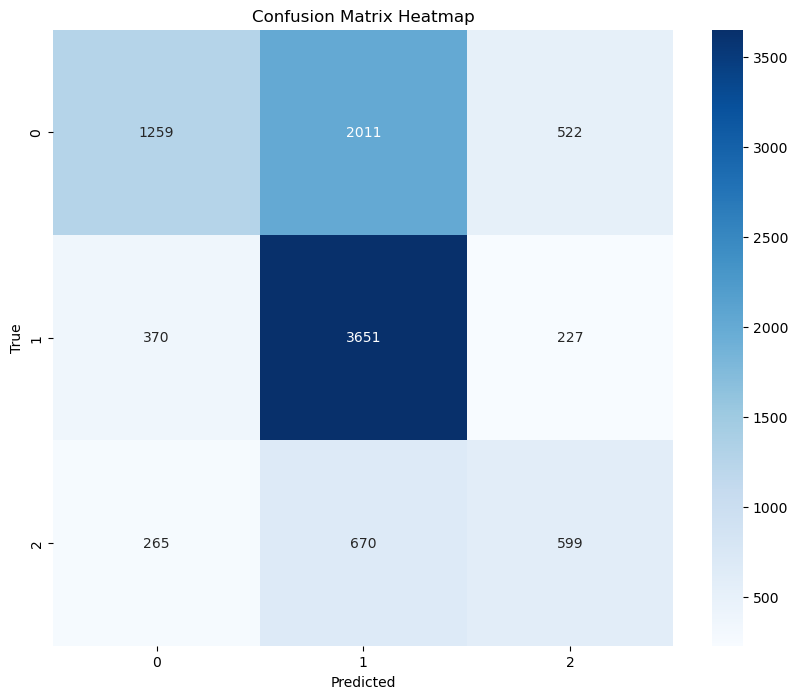

In [34]:
# Calcular matriz de confusión
cm_m2 = confusion_matrix(y_true_m2, y_pred_m2)

# Graficar heatmap con enteros
plt.figure(figsize=(10,8))
sns.heatmap(cm_m2, annot=True, cmap="Blues", cbar=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [35]:
model_m2.save("hongos_m2.keras")

In [36]:
%%time
loss, accuracy = model_m2.evaluate(test_ds_m2)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

300/300 ━━━━━━━━━━━━━━━━━━━━ 125s 416ms/step - accuracy: 0.5754 - loss: 0.9131
Loss: 0.9131
Accuracy: 0.5754
CPU times: total: 18min 14s
Wall time: 2min 4s


# 3) TERCER MODELO: 15% DE LAS IMÁGENES + FINETUNING

In [37]:
train_dir_15 = r"C:\Datasets\imagenes_como_vienen\15%\dataset_train_jpg"
test_dir_15  = r"C:\Datasets\imagenes_como_vienen\15%\dataset_test_jpg"

In [38]:
train_ds_m3 = tf.keras.utils.image_dataset_from_directory(
    train_dir_15,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds_m3 = tf.keras.utils.image_dataset_from_directory(
    test_dir_15,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 34561 files belonging to 3 classes.
Found 9574 files belonging to 3 classes.


In [39]:
class_names = train_ds_m3.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds_m3 = train_ds_m3.prefetch(AUTOTUNE)
test_ds_m3 = test_ds_m3.prefetch(AUTOTUNE)

In [40]:
print(class_names)

['Comestible', 'No comestible', 'Venenoso']


**CHEQUEO DE CLASES**

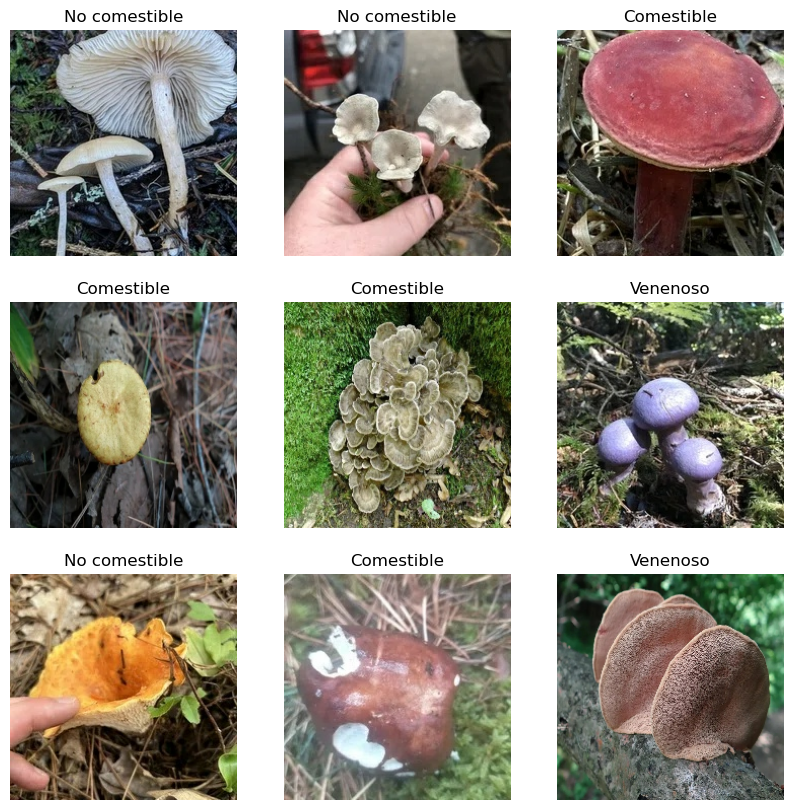

In [41]:
plt.figure(figsize=(10,10))

for images, labels in train_ds_m3.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [42]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

**SE HACE FINE-TUNING**

In [43]:
base_model.trainable = True

In [44]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [45]:
inputs = tf.keras.Input(shape=(224,224,3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# x = base_model(x, training=False)
x = base_model(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    3,
    activation="softmax"
)(x)

model_m3 = tf.keras.Model(inputs, outputs)

In [46]:
model_m3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [47]:
model_m3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_2 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_2 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │           3,843 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 1,209,923 (4.62 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [48]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [49]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [50]:
print(model_m3.count_params())

2261827


In [51]:
%%time
history_m3 = model_m3.fit(
    train_ds_m3,
    validation_data=test_ds_m3,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 711s 641ms/step - accuracy: 0.6418 - loss: 0.7755 - val_accuracy: 0.4512 - val_loss: 2.5113 - learning_rate: 0.0010
Epoch 2/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 708s 655ms/step - accuracy: 0.7083 - loss: 0.6476 - val_accuracy: 0.5539 - val_loss: 1.3705 - learning_rate: 0.0010
Epoch 3/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 706s 653ms/step - accuracy: 0.7548 - loss: 0.5623 - val_accuracy: 0.5125 - val_loss: 2.2413 - learning_rate: 0.0010
Epoch 4/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 713s 660ms/step - accuracy: 0.7969 - loss: 0.4733 - val_accuracy: 0.5718 - val_loss: 1.4815 - learning_rate: 0.0010
Epoch 5/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 711s 658ms/step - accuracy: 0.8402 - loss: 0.3830 - val_accuracy: 0.5708 - val_loss: 1.6180 - learning_rate: 0.0010
Epoch 6/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 701s 649ms/step - accuracy: 0.9159 - loss: 0.2136 - val_accuracy: 0.6110 - val_loss: 1.5705 - learning_rate: 2.0000e-04
CPU times: total: 9h 43min 11s
Wall time: 1h 11m

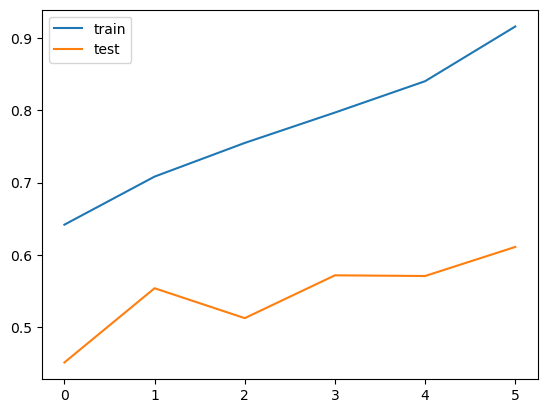

In [52]:
plt.plot(history_m3.history["accuracy"], label="train")
plt.plot(history_m3.history["val_accuracy"], label="test")

plt.legend()
plt.show()

In [53]:
%%time

y_true_m3 = []
y_pred_m3 = []

for x, y in test_ds_m3:
    pred = model_m3.predict(x, verbose=0)

    y_true_m3.extend(y.numpy())
    y_pred_m3.extend(np.argmax(pred, axis=1))

print(classification_report(y_true_m3, y_pred_m3))

              precision    recall  f1-score   support

           0       0.54      0.68      0.60      3792
           1       0.82      0.42      0.55      4248
           2       0.36      0.62      0.46      1534

    accuracy                           0.55      9574
   macro avg       0.57      0.57      0.54      9574
weighted avg       0.64      0.55      0.56      9574

CPU times: total: 17min 44s
Wall time: 3min 9s


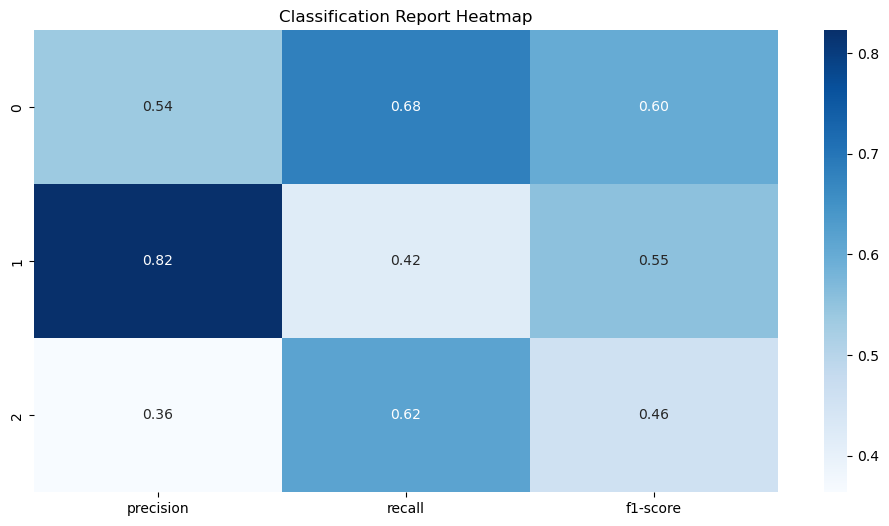

In [54]:
report_m3 = classification_report(y_true_m3, y_pred_m3, output_dict=True)
df_m3 = pd.DataFrame(report_m3).transpose()

plt.figure(figsize=(12,6))
sns.heatmap(df_m3[['precision', 'recall', 'f1-score']].head(3), annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.show()

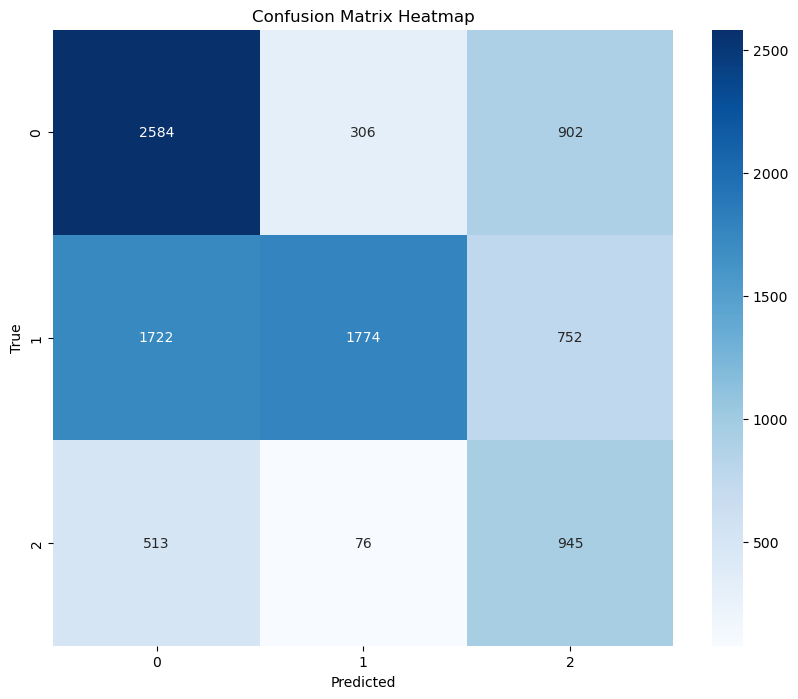

In [55]:
# Calcular matriz de confusión
cm_m3 = confusion_matrix(y_true_m3, y_pred_m3)

# Graficar heatmap con enteros
plt.figure(figsize=(10,8))
sns.heatmap(cm_m3, annot=True, cmap="Blues", cbar=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [56]:
model_m3.save("hongos_m3.keras")

In [57]:
%%time
loss, accuracy = model_m3.evaluate(test_ds_m3)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

300/300 ━━━━━━━━━━━━━━━━━━━━ 129s 431ms/step - accuracy: 0.5539 - loss: 1.3705
Loss: 1.3705
Accuracy: 0.5539
CPU times: total: 17min 11s
Wall time: 2min 9s


# 4) CUARTO MODELO: 15% DE LAS IMÁGENES + FINETUNING + CLASS WEIGHT

In [58]:
train_dir_15 = r"C:\Datasets\imagenes_como_vienen\15%\dataset_train_jpg"
test_dir_15  = r"C:\Datasets\imagenes_como_vienen\15%\dataset_test_jpg"

In [59]:
train_ds_m4 = tf.keras.utils.image_dataset_from_directory(
    train_dir_15,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds_m4 = tf.keras.utils.image_dataset_from_directory(
    test_dir_15,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 34561 files belonging to 3 classes.
Found 9574 files belonging to 3 classes.


In [60]:
class_names = train_ds_m4.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds_m4 = train_ds_m4.prefetch(AUTOTUNE)
test_ds_m4 = test_ds_m4.prefetch(AUTOTUNE)

In [61]:
print(class_names)

['Comestible', 'No comestible', 'Venenoso']


**CHEQUEO DE CLASES**

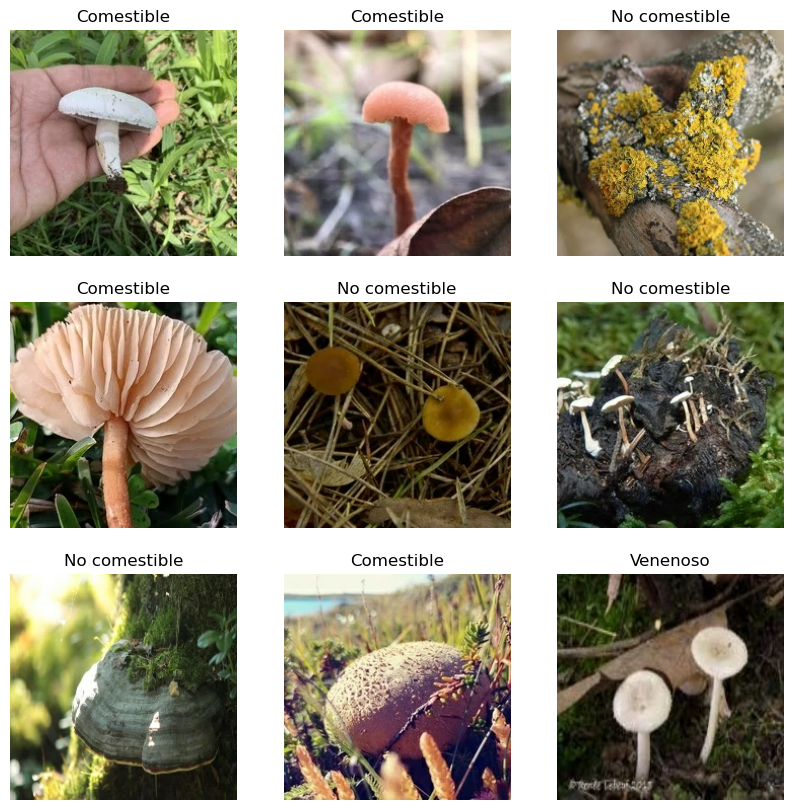

In [62]:
plt.figure(figsize=(10,10))

for images, labels in train_ds_m4.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [63]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

**SE HACE FINE-TUNING**

In [64]:
base_model.trainable = True

In [65]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [66]:
inputs = tf.keras.Input(shape=(224,224,3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# x = base_model(x, training=False)
x = base_model(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    3,
    activation="softmax"
)(x)

model_m4 = tf.keras.Model(inputs, outputs)

In [67]:
model_m4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [68]:
model_m4.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_3 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_3 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │           3,843 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 1,209,923 (4.62 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [69]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [70]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [71]:
print(model_m4.count_params())

2261827


**SE AGREGAN LOS CLASS WEIGHT**

In [72]:
conteos = {}

for i, clase in enumerate(class_names):

    carpeta = os.path.join(train_dir_15, clase)

    cantidad = len([
        f for f in os.listdir(carpeta)
        if os.path.isfile(os.path.join(carpeta, f))
    ])

    conteos[i] = cantidad

print(conteos)

{0: 11880, 1: 16787, 2: 5894}


In [73]:
total = sum(conteos.values())
n_clases = len(conteos)

class_weight = {
    clase: total / (n_clases * cantidad)
    for clase, cantidad in conteos.items()
}

In [74]:
class_weight

{0: 0.9697250280583614, 1: 0.6862651655050536, 2: 1.9545865852279154}

In [75]:
for i in class_weight:
    print(
        f"{class_names[i]}: "
        f"{conteos[i]} imágenes, "
        f"peso={class_weight[i]:.2f}"
    )

Comestible: 11880 imágenes, peso=0.97
No comestible: 16787 imágenes, peso=0.69
Venenoso: 5894 imágenes, peso=1.95


In [76]:
%%time
history_m4 = model_m4.fit(
    train_ds_m4,
    validation_data=test_ds_m4,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight
)

Epoch 1/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 720s 648ms/step - accuracy: 0.5112 - loss: 0.9968 - val_accuracy: 0.5040 - val_loss: 1.0254 - learning_rate: 1.0000e-05
Epoch 2/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 690s 638ms/step - accuracy: 0.6009 - loss: 0.8432 - val_accuracy: 0.5537 - val_loss: 0.9606 - learning_rate: 1.0000e-05
Epoch 3/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 689s 637ms/step - accuracy: 0.6377 - loss: 0.7755 - val_accuracy: 0.5740 - val_loss: 0.9339 - learning_rate: 1.0000e-05
Epoch 4/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 686s 634ms/step - accuracy: 0.6593 - loss: 0.7328 - val_accuracy: 0.5860 - val_loss: 0.9141 - learning_rate: 1.0000e-05
Epoch 5/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 690s 638ms/step - accuracy: 0.6813 - loss: 0.6915 - val_accuracy: 0.6019 - val_loss: 0.8919 - learning_rate: 1.0000e-05
Epoch 6/10
1081/1081 ━━━━━━━━━━━━━━━━━━━━ 692s 640ms/step - accuracy: 0.7024 - loss: 0.6557 - val_accuracy: 0.6020 - val_loss: 0.8944 - learning_rate: 1.0000e-05
Epoch 7/10
1081/1081 ━━━━━━━

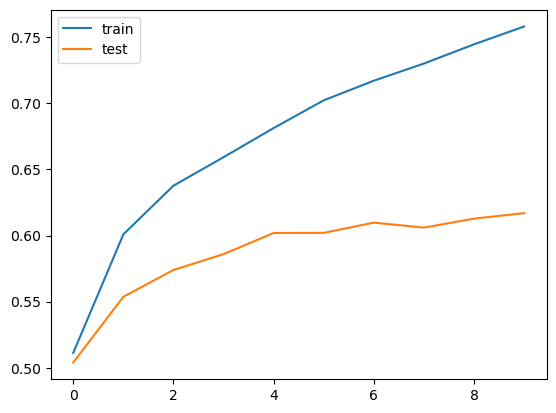

In [77]:
plt.plot(history_m4.history["accuracy"], label="train")
plt.plot(history_m4.history["val_accuracy"], label="test")

plt.legend()
plt.show()

In [78]:
%%time

y_true_m4 = []
y_pred_m4 = []

for x, y in test_ds_m4:
    pred = model_m4.predict(x, verbose=0)

    y_true_m4.extend(y.numpy())
    y_pred_m4.extend(np.argmax(pred, axis=1))

print(classification_report(y_true_m4, y_pred_m4))

              precision    recall  f1-score   support

           0       0.60      0.64      0.62      3792
           1       0.74      0.61      0.67      4248
           2       0.41      0.53      0.46      1534

    accuracy                           0.61      9574
   macro avg       0.58      0.59      0.58      9574
weighted avg       0.63      0.61      0.62      9574

CPU times: total: 19min 11s
Wall time: 3min 9s


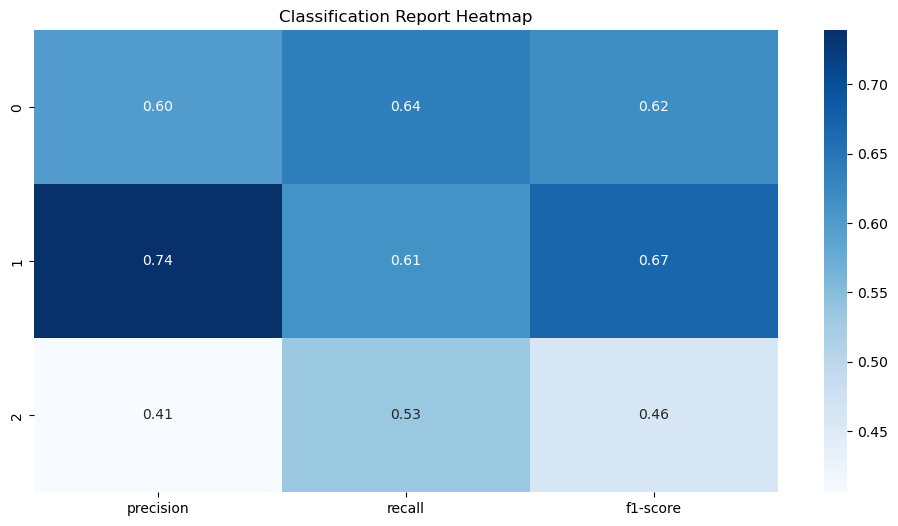

In [79]:
report_m4 = classification_report(y_true_m4, y_pred_m4, output_dict=True)
df_m4 = pd.DataFrame(report_m4).transpose()

plt.figure(figsize=(12,6))
sns.heatmap(df_m4[['precision', 'recall', 'f1-score']].head(3), annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.show()

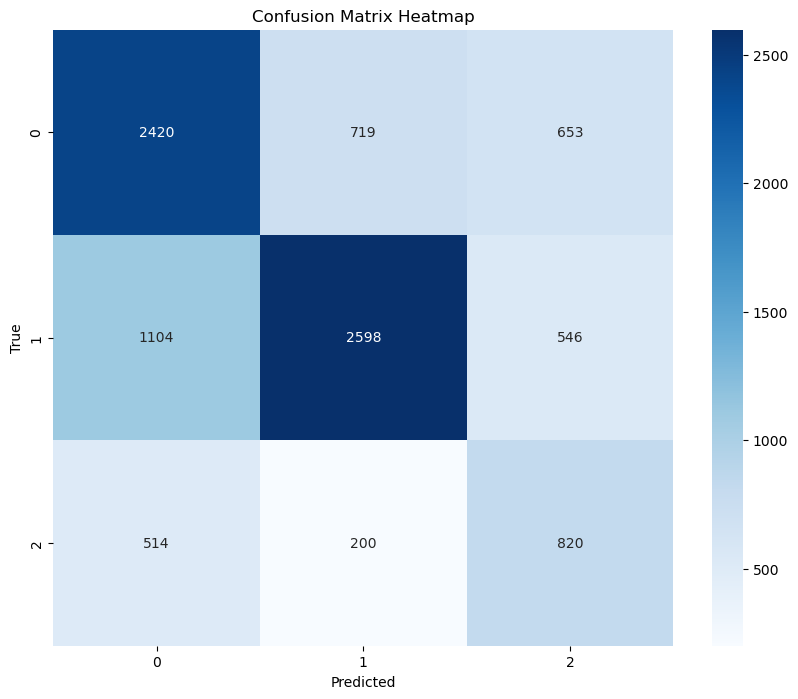

In [80]:
# Calcular matriz de confusión
cm_m4 = confusion_matrix(y_true_m4, y_pred_m4)

# Graficar heatmap con enteros
plt.figure(figsize=(10,8))
sns.heatmap(cm_m4, annot=True, cmap="Blues", cbar=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [81]:
model_m4.save("hongos_m4.keras")

In [82]:
%%time
loss, accuracy = model_m4.evaluate(test_ds_m4)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

300/300 ━━━━━━━━━━━━━━━━━━━━ 126s 421ms/step - accuracy: 0.6098 - loss: 0.8886
Loss: 0.8886
Accuracy: 0.6098
CPU times: total: 17min 47s
Wall time: 2min 6s


# 5) QUINTO MODELO: 15% DE LAS IMÁGENES + FINETUNING + CLASS WEIGHT + DATA AUGMENTATION

In [83]:
train_dir_15_aug = r"C:\Datasets\imagenes_como_vienen\15%\dataset_train_jpg_aug"
test_dir_15_aug  = r"C:\Datasets\imagenes_como_vienen\15%\dataset_test_jpg"

In [84]:
train_ds_m5 = tf.keras.utils.image_dataset_from_directory(
    train_dir_15_aug,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds_m5 = tf.keras.utils.image_dataset_from_directory(
    test_dir_15_aug,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 39667 files belonging to 3 classes.
Found 9574 files belonging to 3 classes.


In [85]:
class_names = train_ds_m5.class_names

AUTOTUNE = tf.data.AUTOTUNE

train_ds_m5 = train_ds_m5.prefetch(AUTOTUNE)
test_ds_m5 = test_ds_m5.prefetch(AUTOTUNE)

In [86]:
print(class_names)

['Comestible', 'No comestible', 'Venenoso']


**CHEQUEO DE CLASES**

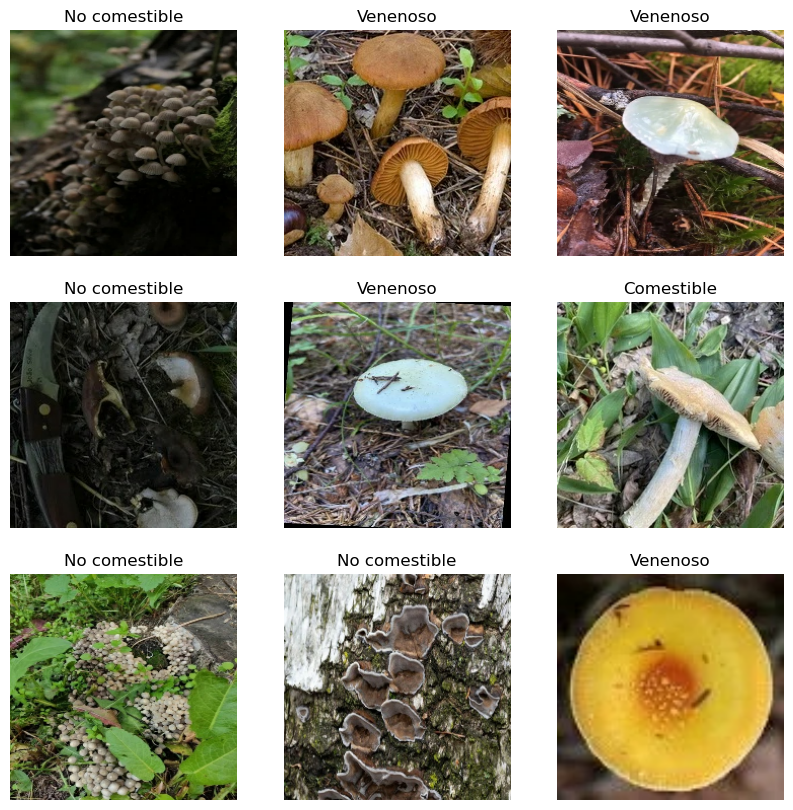

In [87]:
plt.figure(figsize=(10,10))

for images, labels in train_ds_m5.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [88]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

**SE HACE FINE-TUNING**

In [89]:
base_model.trainable = True

In [90]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [91]:
inputs = tf.keras.Input(shape=(224,224,3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

x = base_model(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    3,
    activation="softmax"
)(x)

model_m5 = tf.keras.Model(inputs, outputs)

In [92]:
model_m5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [93]:
model_m5.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_4 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_4 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │           3,843 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 1,209,923 (4.62 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [94]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [95]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [96]:
print(model_m5.count_params())

2261827


**SE AGREGAN LOS CLASS WEIGHT**

In [97]:
class_weight = {
    0: 1.0,
    1: 1.0,
    2: 1.15
}

In [99]:
conteos = {}

for i, clase in enumerate(class_names):

    carpeta = os.path.join(train_dir_15_aug, clase)

    cantidad = len([
        f for f in os.listdir(carpeta)
        if os.path.isfile(os.path.join(carpeta, f))
    ])

    conteos[i] = cantidad

print(conteos)

{0: 11880, 1: 16787, 2: 11000}


In [100]:
for i in class_weight:
    print(
        f"{class_names[i]}: "
        f"{conteos[i]} imágenes, "
        f"peso={class_weight[i]:.2f}"
    )

Comestible: 11880 imágenes, peso=1.00
No comestible: 16787 imágenes, peso=1.00
Venenoso: 11000 imágenes, peso=1.15


In [101]:
%%time
history_m5 = model_m5.fit(
    train_ds_m5,
    validation_data=test_ds_m5,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight
)

Epoch 1/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 806s 635ms/step - accuracy: 0.5556 - loss: 0.9701 - val_accuracy: 0.5473 - val_loss: 0.9778 - learning_rate: 1.0000e-05
Epoch 2/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 773s 623ms/step - accuracy: 0.6563 - loss: 0.7811 - val_accuracy: 0.5862 - val_loss: 0.9270 - learning_rate: 1.0000e-05
Epoch 3/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 782s 631ms/step - accuracy: 0.6921 - loss: 0.7080 - val_accuracy: 0.6075 - val_loss: 0.8888 - learning_rate: 1.0000e-05
Epoch 4/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 781s 630ms/step - accuracy: 0.7180 - loss: 0.6599 - val_accuracy: 0.6164 - val_loss: 0.8760 - learning_rate: 1.0000e-05
Epoch 5/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 780s 629ms/step - accuracy: 0.7380 - loss: 0.6192 - val_accuracy: 0.6254 - val_loss: 0.8619 - learning_rate: 1.0000e-05
Epoch 6/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 780s 629ms/step - accuracy: 0.7541 - loss: 0.5879 - val_accuracy: 0.6289 - val_loss: 0.8597 - learning_rate: 1.0000e-05
Epoch 7/10
1240/1240 ━━━━━━━

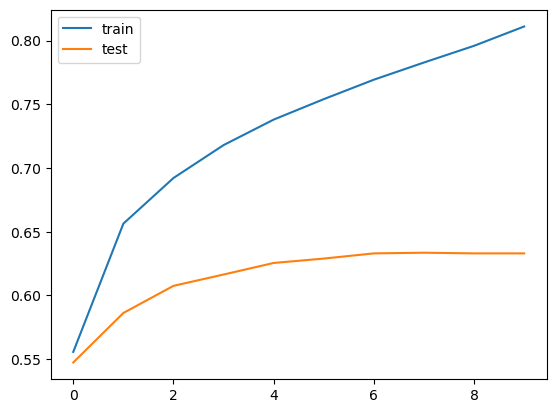

In [102]:
plt.plot(history_m5.history["accuracy"], label="train")
plt.plot(history_m5.history["val_accuracy"], label="test")

plt.legend()
plt.show()

In [103]:
%%time

y_true_m5 = []
y_pred_m5 = []

for x, y in test_ds_m5:
    pred = model_m5.predict(x, verbose=0)

    y_true_m5.extend(y.numpy())
    y_pred_m5.extend(np.argmax(pred, axis=1))

print(classification_report(y_true_m5, y_pred_m5))

              precision    recall  f1-score   support

           0       0.62      0.58      0.60      3792
           1       0.67      0.74      0.71      4248
           2       0.49      0.43      0.46      1534

    accuracy                           0.63      9574
   macro avg       0.60      0.59      0.59      9574
weighted avg       0.62      0.63      0.63      9574

CPU times: total: 19min 16s
Wall time: 3min 5s


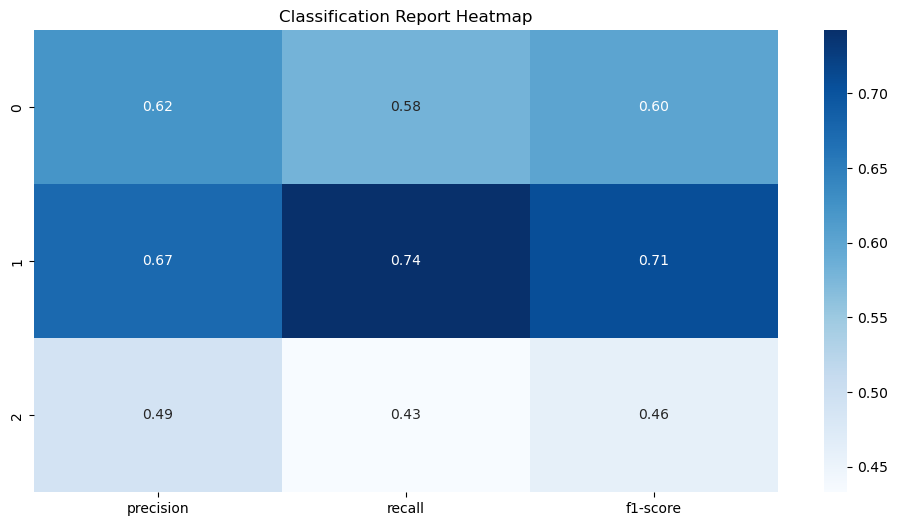

In [104]:
report_m5 = classification_report(y_true_m5, y_pred_m5, output_dict=True)
df_m5 = pd.DataFrame(report_m5).transpose()

plt.figure(figsize=(12,6))
sns.heatmap(df_m5[['precision', 'recall', 'f1-score']].head(3), annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.show()

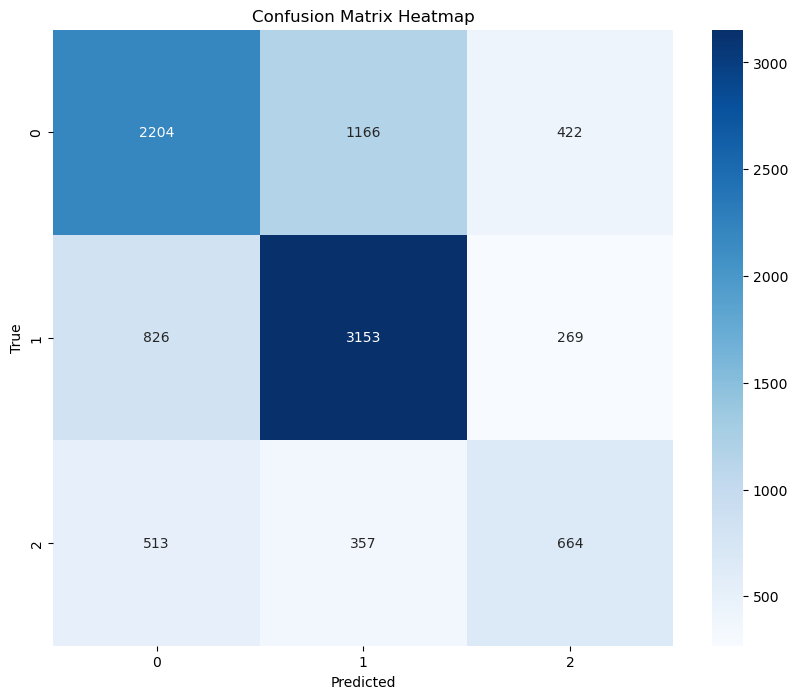

In [105]:
# Calcular matriz de confusión
cm_m5 = confusion_matrix(y_true_m5, y_pred_m5)

# Graficar heatmap con enteros
plt.figure(figsize=(10,8))
sns.heatmap(cm_m5, annot=True, cmap="Blues", cbar=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [106]:
model_m5.save("hongos_m5.keras")

In [107]:
%%time
loss, accuracy = model_m5.evaluate(test_ds_m5)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

300/300 ━━━━━━━━━━━━━━━━━━━━ 127s 423ms/step - accuracy: 0.6289 - loss: 0.8597
Loss: 0.8597
Accuracy: 0.6289
CPU times: total: 18min 12s
Wall time: 2min 6s


# COMPARACIÓN DE LOS 5 MODELOS

In [108]:
resultados = []

experimentos = [
    ("M1", model_m1, test_ds_m1),
    ("M2", model_m2, test_ds_m2),
    ("M3", model_m3, test_ds_m3),
    ("M4", model_m4, test_ds_m4),
    ("M5", model_m5, test_ds_m5)
]

for nombre, modelo, dataset in experimentos:

    loss, accuracy = modelo.evaluate(
        dataset,
        verbose=0
    )

    resultados.append({
        "Modelo": nombre,
        "Loss": loss,
        "Accuracy": accuracy
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,Modelo,Loss,Accuracy
0,M1,0.900858,0.571749
1,M2,0.913113,0.575413
2,M3,1.370473,0.553896
3,M4,0.888566,0.609776
4,M5,0.859679,0.628891


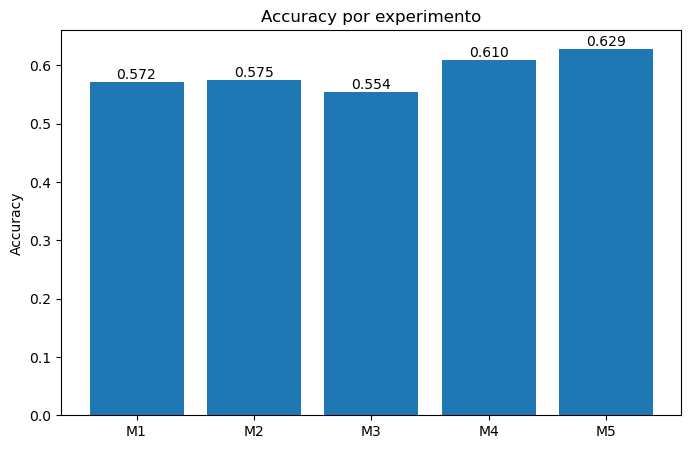

In [109]:
fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    df_resultados["Modelo"],
    df_resultados["Accuracy"]
)

for bar in bars:

    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.3f}",
        ha="center",
        va="bottom"
    )

ax.set_title("Accuracy por experimento")
ax.set_ylabel("Accuracy")

plt.show()

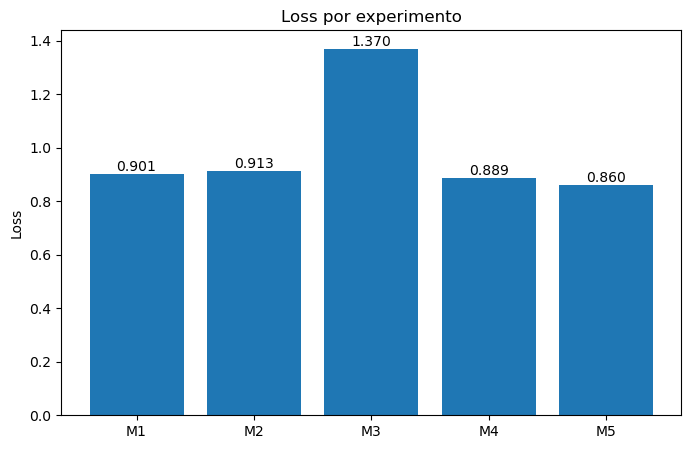

In [110]:
fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    df_resultados["Modelo"],
    df_resultados["Loss"]
)

for bar in bars:

    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.3f}",
        ha="center",
        va="bottom"
    )

ax.set_title("Loss por experimento")
ax.set_ylabel("Loss")

plt.show()

# OPTIMIZACIONES EXTRA:

## QUANTIZATION:

In [111]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_m5)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

tflite_model = converter.convert()

with open("modelo_quantizado.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\santi\AppData\Local\Temp\tmp_toma553\assets


INFO:tensorflow:Assets written to: C:\Users\santi\AppData\Local\Temp\tmp_toma553\assets


Saved artifact at 'C:\Users\santi\AppData\Local\Temp\tmp_toma553'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_798')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1623375016976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1623221209040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1623221208848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1623221208080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1623221209616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1623221208656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1623221209232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1623221209424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1623221207696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1623221210576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

In [112]:
interpreter = tf.lite.Interpreter(
    model_path="modelo_quantizado.tflite"
)

interpreter.allocate_tensors()

C:\Users\santi\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [113]:
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

**SE COMPARAN LOS TIEMPOS DE RESPUESTA PARA 100 CASOS TANTO EN KERAS COMO EN EL QUANTIZADO**

In [114]:
x_batch, _ = next(iter(test_ds_m5))

x = x_batch[0:1]

inicio = time.time()

for _ in range(100):
    _ = model_m5.predict(x, verbose=0)

fin = time.time()
tiempo_Keras = (fin-inicio)/100

print("Keras:", tiempo_Keras)

Keras: 0.24041759967803955


In [115]:
inicio = time.time()

for _ in range(100):

    interpreter.set_tensor(
        input_details[0]['index'],
        x.numpy().astype(np.float32)
    )

    interpreter.invoke()

fin = time.time()
tiempo_Quantization = (fin-inicio)/100

print("TFLite:", tiempo_Quantization)

TFLite: 0.13340803861618042


In [116]:
modelo_keras = "hongos_m5.keras"
modelo_tflite = "modelo_quantizado.tflite"

**SE ANALIZA EL TAMAÑO DE LOS .KERAS**

In [117]:
tamano_keras = os.path.getsize(modelo_keras) / (1024 * 1024)
tamano_tflite = os.path.getsize(modelo_tflite) / (1024 * 1024)

df_tamano = pd.DataFrame({
    "Modelo": ["Keras", "Quantizado"],
    "MB": [tamano_keras, tamano_tflite]
})

df_tamano

,Modelo,MB
0,Keras,18.435483
1,Quantizado,2.394737


In [118]:
df_latencia = pd.DataFrame({
    "Modelo": ["Keras", "Quantizado"],
    "Segundos": [tiempo_Keras, tiempo_Quantization]
})

df_latencia

,Modelo,Segundos
0,Keras,0.240418
1,Quantizado,0.133408


**COMPARACIÓN DEL TAMAÑO EN LA VERSIÓN NORMAL VERSUS QUANTIZADO**

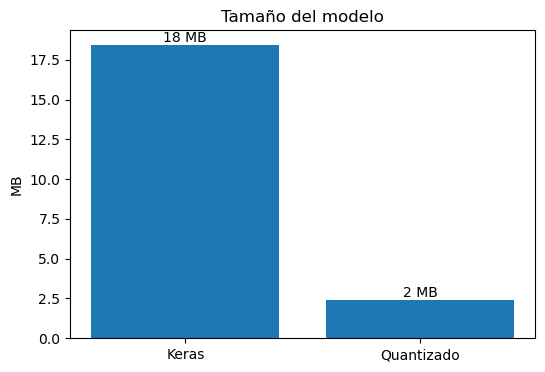

In [119]:
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(
    df_tamano["Modelo"],
    df_tamano["MB"]
)

for bar in bars:
    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.0f} MB",
        ha="center",
        va="bottom"
    )

ax.set_ylabel("MB")
ax.set_title("Tamaño del modelo")

plt.show()

**LO MISMO CON LA LATENCIA QUE PRESENTAN AMBOS MODELOS**

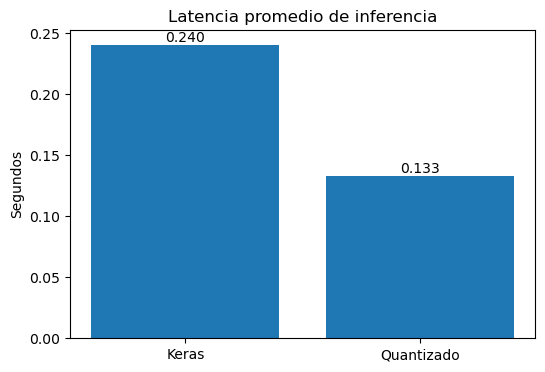

In [120]:
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(
    df_latencia["Modelo"],
    df_latencia["Segundos"]
)

for bar in bars:
    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.3f}",
        ha="center",
        va="bottom"
    )

ax.set_ylabel("Segundos")
ax.set_title("Latencia promedio de inferencia")

plt.show()

**IMPACTO DE LA QUANTIZACION:**

In [121]:
reduccion_tamano = (
    1 - tamano_tflite / tamano_keras
) * 100

mejora_latencia = (
    1 - tiempo_Quantization / tiempo_Keras
) * 100

print(f"Reducción tamaño: {reduccion_tamano:.1f}%")
print(f"Mejora latencia: {mejora_latencia:.1f}%")

Reducción tamaño: 87.0%
Mejora latencia: 44.5%


# RENDIMIENTO DEL QUANTIZADO:

In [122]:
print(input_details[0]["shape"])

[  1 224 224   3]


In [123]:
interpreter.resize_tensor_input(
    input_details[0]["index"],
    [32,224,224,3]
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [124]:
%%time
y_true = []
y_pred = []

for x_batch, y_batch in test_ds_m5:

    batch_size_real = x_batch.shape[0]

    # Si el último batch tiene menos de 32 imágenes
    if batch_size_real < 32:

        padding = np.zeros(
            (32 - batch_size_real, 224, 224, 3),
            dtype=np.float32
        )

        x_input = np.concatenate(
            [x_batch.numpy(), padding],
            axis=0
        )

    else:

        x_input = x_batch.numpy()

    interpreter.set_tensor(
        input_details[0]["index"],
        x_input.astype(np.float32)
    )

    interpreter.invoke()

    pred = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # Ignorar predicciones del padding
    pred = pred[:batch_size_real]

    y_true.extend(
        y_batch.numpy()
    )

    y_pred.extend(
        np.argmax(pred, axis=1)
    )

CPU times: total: 22min
Wall time: 21min 27s


In [125]:
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.6350    0.5593    0.5948      3792
           1     0.6625    0.7611    0.7084      4248
           2     0.5000    0.4413    0.4688      1534

    accuracy                         0.6299      9574
   macro avg     0.5992    0.5872    0.5907      9574
weighted avg     0.6256    0.6299    0.6250      9574



In [126]:
cm = confusion_matrix(
    y_true,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=["Clase 0","Clase 1","Clase 2"],
    columns=["Pred 0","Pred 1","Pred 2"]
)

cm_df

,Pred 0,Pred 1,Pred 2
Clase 0,2121,1259,412
Clase 1,750,3233,265
Clase 2,469,388,677


# SE COMPARAN LOS DOS MODELOS

In [127]:
loss_m5, acc_m5 = model_m5.evaluate(
    test_ds_m5,
    verbose=0
)

print(acc_m5)

0.6288907527923584


In [128]:
from sklearn.metrics import accuracy_score

acc_tflite = accuracy_score(
    y_true,
    y_pred
)

print(acc_tflite)

0.6299352412784625


In [129]:
df_acc = pd.DataFrame({
    "Modelo": ["M5", "M5 Quantizado"],
    "Accuracy": [acc_m5, acc_tflite]
})

df_acc

,Modelo,Accuracy
0,M5,0.628891
1,M5 Quantizado,0.629935


In [130]:
delta = acc_tflite - acc_m5

print(f"Diferencia absoluta: {delta:.4f}")
print(f"Diferencia porcentual: {delta*100:.2f}%")

Diferencia absoluta: 0.0010
Diferencia porcentual: 0.10%


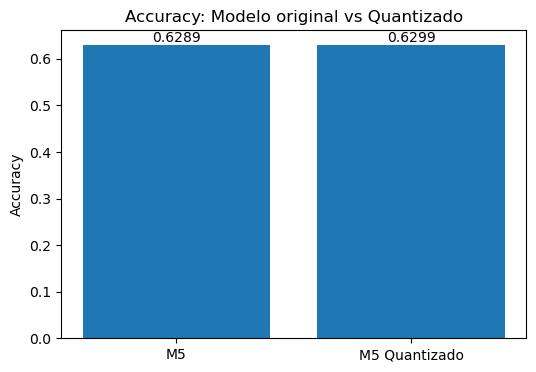

In [131]:
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(
    df_acc["Modelo"],
    df_acc["Accuracy"]
)

for bar in bars:

    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.4f}",
        ha="center",
        va="bottom"
    )

ax.set_ylabel("Accuracy")
ax.set_title("Accuracy: Modelo original vs Quantizado")

plt.show()

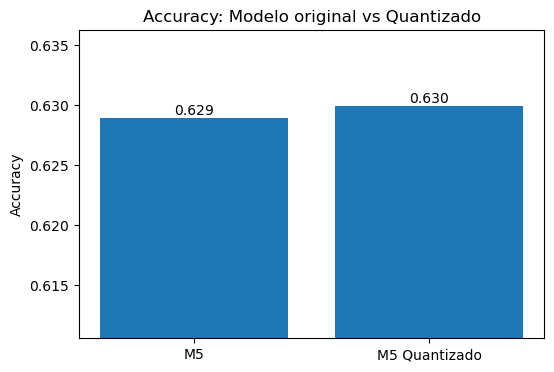

In [132]:
fig, ax = plt.subplots(figsize=(6,4))

bars = ax.bar(
    df_acc["Modelo"],
    df_acc["Accuracy"]
)

for bar in bars:

    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f"{altura:.3f}",
        ha="center",
        va="bottom"
    )

ax.set_ylim(acc_m5 / 1.03, max(df_acc["Accuracy"]) * 1.01)

ax.set_ylabel("Accuracy")
ax.set_title("Accuracy: Modelo original vs Quantizado")

plt.show()